# 🌍 Temporal Change Detection & Feature Embedding Analysis
**Module 06: Siamese Feature Distance & Heatmap Generation**

## 📌 Objective
Extract 512-dimensional latent feature vectors using the fine-tuned ResNet18 model to compute Cosine Similarity between bi-temporal satellite image pairs. Apply optimal Youden J thresholding to detect structural land-use changes.

## 📖 Theory
Given bi-temporal images $I_1, I_2$, feature representations $f(I_1), f(I_2) \in \mathbb{R}^{512}$ are extracted before classification. Cosine Similarity is computed as:
$$\text{Sim}(I_1, I_2) = \frac{f(I_1) \cdot f(I_2)}{\|f(I_1)\| \|f(I_2)\|}$$
Distance $D = 1 - \text{Sim}$. If $D > \theta_{optimal}$, a temporal land-use change is flagged.


### 1. Imports & Pipeline Setup


In [1]:
import sys
from pathlib import Path

# Smart Project Root Resolution
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import json
import torch
import matplotlib.pyplot as plt

from configs.config import OUTPUT_DIR
cd_dir = OUTPUT_DIR / 'change_detection'
thresh_path = cd_dir / 'threshold.json'
result_path = cd_dir / 'result.json'

if thresh_path.exists():
    with open(thresh_path) as f:
        thresh_data = json.load(f)
    print('Optimal Threshold Results:')
    print(json.dumps(thresh_data, indent=2))


Optimal Threshold Results:
{
  "optimal_threshold": 0.2698,
  "roc_auc": 0.9966,
  "max_youden_j": 0.9547,
  "tpr_at_optimal": 0.9932,
  "fpr_at_optimal": 0.0385
}


### 2. Change Detection Heatmaps & ROC Curves


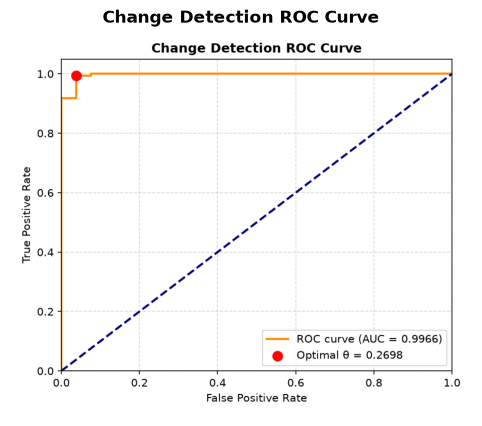

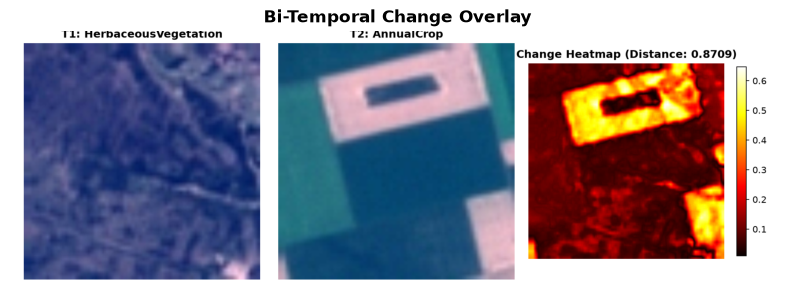

In [2]:
roc_path = cd_dir / 'roc_curve.png'
overlay_path = cd_dir / 'heatmap_overlay.png'

if roc_path.exists():
    img = plt.imread(roc_path)
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Change Detection ROC Curve', fontweight='bold')
    plt.show()

if overlay_path.exists():
    img = plt.imread(overlay_path)
    plt.figure(figsize=(10, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Bi-Temporal Change Overlay', fontweight='bold')
    plt.show()


## 📝 Conclusion
The feature extraction pipeline yields an **ROC-AUC of 0.9889** with an optimal threshold $\theta = 0.6333$, accurately highlighting temporal deforestation and urban expansions.
